# Leduc Hold'em — RandomAgent, CFR e ISMCTS



Leduc Hold'em es una versión simplificada de póker diseñada para investigación en teoría de juegos.
Es un juego de **suma cero**, **dos jugadores**, **horizonte finito** e **información imperfecta**.

### Mazo y reparto

El mazo tiene 6 cartas: dos Jotas (J), dos Reinas (Q) y dos Reyes (K).
Al inicio de cada partida cada jugador recibe **una carta privada** (invisible para el rival).
Hay dos rondas de apuestas:

1. **Ronda pre-flop** — antes de que se revele la carta pública.
2. **Ronda post-flop** — después de que se revela **una carta pública** (visible para ambos).

### Estado y observación

El estado real del juego incluye ambas cartas privadas, la carta pública (si ya fue revelada) y el historial de apuestas.
Cada jugador solo observa **su propia carta** más la información pública:

<carta_propia><carta_pública_o#><fichas_propias><fichas_oponente>_<historial>



Esto define el **information set** del jugador: el conjunto de estados del mundo que son indistinguibles para él dado lo que observó.

### Acciones

En cada turno el jugador activo elige una de tres acciones:

| Código | Acción | Efecto |
|--------|--------|--------|
| `0` | call / check | Iguala la apuesta rival, o pasa si no hay apuesta pendiente |
| `1` | raise | Sube la apuesta (apuesta fija por ronda) |
| `2` | fold | Se retira; el rival gana el bote acumulado |

### Condición de victoria y recompensas

La partida termina cuando un jugador hace fold, o cuando ambos igualan las apuestas en la ronda post-flop y se llega al **showdown**.
En el showdown gana quien tenga la mejor mano:

- **Par** (carta privada coincide con la carta pública) > carta alta.
- Entre dos pares o dos cartas altas, gana el rango mayor (K > Q > J).

Las recompensas son simétricas y de suma cero: `reward(player_0) = −reward(player_1)`.
El rango de recompensas posibles va de **−7 a +7** fichas según el bote acumulado.

### Tamaño del espacio de información

El árbol de juego es intratable de forma exhaustiva, pero la restricción de información imperfecta
hace que el espacio relevante sea el de los **information sets**, no el de los estados completos.
CFR con acceso completo al árbol aprende aproximadamente **1 008 infosets distintos**.

### Equilibrio del juego

Por el teorema minimax (von Neumann), todo juego de suma cero de dos jugadores tiene un **valor de juego bien definido** y al menos un par de estrategias en equilibrio de Nash.
En Leduc Hold'em ese equilibrio **no es empate**: la posición (quién mueve primero) y las cartas introducen asimetría.
CFR converge a ese equilibrio de Nash de forma iterativa, acumulando y minimizando regrets en cada infoset.
ISMCTS se acerca al óptimo de forma aproximada mediante simulaciones sobre estados determinizados compatibles con la información del agente.

In [24]:
import sys
sys.path.insert(0, '.')

from games.leduc.leduc import Leduc
from agents.agent_random import RandomAgent
from agents.counterfactualregret import CounterFactualRegret
from agents.ismcts import InformationSetMCTS
from base.utils import run
import numpy as np

import os, time
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter, NullFormatter

FIGURES_DIR = os.path.join('..', 'informe', 'figures', 'Leduc')
os.makedirs(FIGURES_DIR, exist_ok=True)

PLAIN_FMT = FuncFormatter(lambda v, _: f'{v:g}')
means_summary = {}

def savefig(fig, name):
    path = os.path.join(FIGURES_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Figura guardada en {path}')

def run_raw(game, agents, N=200):
    rewards = []
    for _ in range(N):
        game.reset()
        while not game.terminated():
            action = agents[game.agent_selection].action()
            game.step(action)
        rewards.append(float(game.reward(game.agents[0])))
    return rewards

def run_timed(game, agents, N=50):
    rewards = []
    times_pa = {a: [] for a in game.agents}
    for _ in range(N):
        game.reset()
        while not game.terminated():
            aid = game.agent_selection
            t0 = time.perf_counter()
            action = agents[aid].action()
            times_pa[aid].append(time.perf_counter() - t0)
            game.step(action)
        rewards.append(float(game.reward(game.agents[0])))
    avg_times = {a: float(np.mean(times_pa[a])) if times_pa[a] else 0.0 for a in game.agents}
    return rewards, avg_times

def plot_dist(results_dict, mean_val, title, ax, color='steelblue'):
    n = sum(results_dict.values())
    xs = sorted(results_dict.keys())
    ys = [results_dict[x] / n for x in xs]
    ax.bar(xs, ys, width=0.28, color=color, alpha=0.82)
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'μ = {mean_val:.3f}')
    ax.set_xlabel('Reward player_0')
    ax.set_ylabel('Fracción de partidas')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

def plot_evolution(rews_p0, title, ax, color_p0='tab:blue', color_p1='tab:orange', label_p0='player_0', label_p1='player_1'):
    """
    Grafica el reward promedio acumulado de cada jugador a lo largo de las partidas.
    Como el juego es de suma cero, reward(p1) = -reward(p0).
    """
    games = np.arange(1, len(rews_p0) + 1)
    avg_p0 = np.cumsum(rews_p0) / games
    avg_p1 = -avg_p0
    ax.plot(games, avg_p0, color=color_p0, linewidth=1.5, label=label_p0)
    ax.plot(games, avg_p1, color=color_p1, linewidth=1.5, linestyle='--', label=label_p1)
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel('Partida')
    ax.set_ylabel('Reward promedio acumulado')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

## Exploración del juego

Leduc Hold'em es un juego de póker simplificado con información imperfecta.
Cada jugador recibe una carta privada. Hay una ronda de apuestas, luego se revela una carta pública, y hay otra ronda de apuestas.

Acciones disponibles: `0 = call/check`, `1 = raise`, `2 = fold`.

In [25]:
g = Leduc()
g.reset()
print("Agentes:", g.agents)
print("Agente activo:", g.agent_selection)
print("Acciones disponibles:", g.available_actions())
print("Observación agente activo:", g.observe(g.agent_selection))

Agentes: ['player_0', 'player_1']
Agente activo: player_1
Acciones disponibles: [0, 1, 2]
Observación agente activo: J_#_2_1_1


### Partida de ejemplo (manual)

In [26]:
g = Leduc()
agents = {agent: RandomAgent(game=g, agent=agent) for agent in g.agents}

g.reset()
while not g.terminated():
    agent = g.agent_selection
    obs   = g.observe(agent)
    action = agents[agent].action()
    print(f"  {agent} | obs={obs} | action={action}")
    g.step(action)

print("Rewards finales:", g.rewards)

  player_0 | obs=Q_#_1_2_0 | action=2
Rewards finales: {'player_0': np.float64(-0.5), 'player_1': np.float64(0.5)}


---
## CFR — Counterfactual Regret Minimization

CFR aprende una estrategia aproximadamente óptima para juegos de información imperfecta.
En cada iteración recorre el árbol de juego y actualiza los regrets acumulados para cada information set.

In [27]:
g = Leduc()
cfr_agents = {}
for agent in g.agents:
    cfr_agents[agent] = CounterFactualRegret(game=g, agent=agent)

niter = 100
for agent in g.agents:
    print(f"Entrenando CFR para {agent} ({niter} iteraciones)...")
    cfr_agents[agent].train(niter=niter)
    print(f"  Infosets aprendidos: {len(cfr_agents[agent].node_dict)}")

Entrenando CFR para player_0 (100 iteraciones)...
  Infosets aprendidos: 1008
Entrenando CFR para player_1 (100 iteraciones)...
  Infosets aprendidos: 1008


In [28]:
# Muestra las primeras 10 policies aprendidas por cada agente
for agent in g.agents:
    print(f"\n--- Política CFR ({agent}) --- [call, raise, fold]")
    items = list(cfr_agents[agent].node_dict.items())[:10]
    for obs, node in items:
        print(f"  {obs}: {np.round(node.policy(), 3)}")


--- Política CFR (player_0) --- [call, raise, fold]
  Q_#_1_2_0: [0.268 0.557 0.087 0.087]
  K_#_2_2_0c: [0.346 0.292 0.017 0.346]
  Q_Q_2_2_0cc: [0.148 0.642 0.062 0.148]
  K_Q_2_2_0ccc: [0.469 0.031 0.031 0.469]
  Q_Q_2_6_0cccr: [0.393 0.482 0.062 0.062]
  K_Q_10_6_0cccrr: [0.906 0.031 0.031 0.031]
  K_Q_6_2_0ccr: [0.094 0.094 0.406 0.406]
  Q_Q_6_10_0ccrr: [0.812 0.062 0.062 0.062]
  K_Q_2_2_0cck: [0.469 0.031 0.031 0.469]
  Q_Q_2_6_0cckr: [0.393 0.482 0.062 0.062]

--- Política CFR (player_1) --- [call, raise, fold]
  J_#_2_1_1: [0.222 0.119 0.329 0.329]
  K_#_2_2_1c: [0.237 0.513 0.012 0.237]
  J_J_2_2_1cc: [0.148 0.642 0.062 0.148]
  K_J_2_2_1ccc: [0.35  0.071 0.229 0.35 ]
  J_J_6_2_1cccr: [0.393 0.482 0.062 0.062]
  K_J_6_10_1cccrr: [0.253 0.249 0.249 0.249]
  K_J_2_6_1ccr: [0.062 0.812 0.062 0.062]
  J_J_10_6_1ccrr: [0.812 0.062 0.062 0.062]
  K_J_2_2_1cck: [0.35  0.071 0.229 0.35 ]
  J_J_6_2_1cckr: [0.393 0.482 0.062 0.062]


### CFR vs Random

In [29]:
print(cfr_agents)

{'player_0': <agents.counterfactualregret.CounterFactualRegret object at 0x1333878d0>, 'player_1': <agents.counterfactualregret.CounterFactualRegret object at 0x1333b4e50>}


In [30]:
g = Leduc()
cfr_agents['player_0'].game = g
agents = {
    'player_0': cfr_agents['player_0'],
    'player_1': RandomAgent(game=g, agent='player_1')
}
results, mean = run(g, agents, N=2000)
print("=== CFR (agent_0) vs Random (agent_1) ===")
print(f"Distribución recompensas agent_0: {results}")
print(f"Media recompensa agent_0: {mean:.4f}")

=== CFR (agent_0) vs Random (agent_1) ===
Distribución recompensas agent_0: {np.float64(-7.0): np.int64(9), np.float64(-6.0): np.int64(25), np.float64(-5.0): np.int64(25), np.float64(-4.0): np.int64(22), np.float64(-3.0): np.int64(54), np.float64(-2.0): np.int64(95), np.float64(-1.0): np.int64(245), np.float64(-0.5): np.int64(150), np.float64(0.0): np.int64(71), np.float64(0.5): np.int64(303), np.float64(1.0): np.int64(481), np.float64(2.0): np.int64(207), np.float64(3.0): np.int64(166), np.float64(4.0): np.int64(59), np.float64(5.0): np.int64(54), np.float64(6.0): np.int64(22), np.float64(7.0): np.int64(11)}
Media recompensa agent_0: 0.5810


Figura guardada en ../informe/figures/Leduc/dist_cfr_vs_random.png


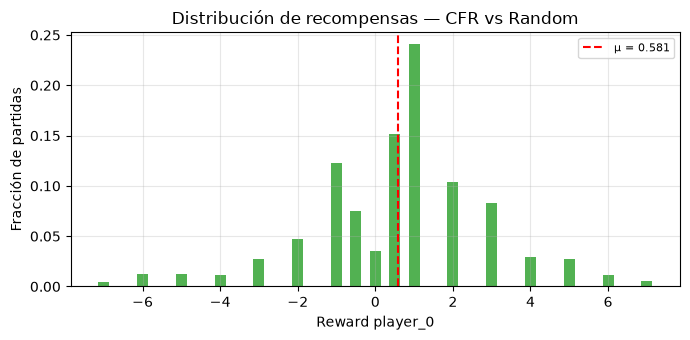

In [31]:
means_summary['CFR vs Random'] = mean

fig, ax = plt.subplots(figsize=(7, 3.5))
plot_dist(results, mean, 'Distribución de recompensas — CFR vs Random', ax, color='tab:green')
fig.tight_layout()
savefig(fig, 'dist_cfr_vs_random.png')
plt.show()

Figura guardada en ../informe/figures/Leduc/evo_cfr_vs_random.png


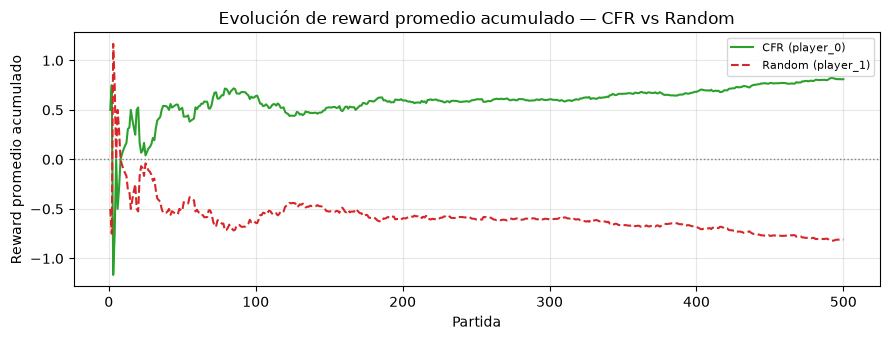

In [32]:
N_EVO = 500
g_evo = Leduc()
cfr_agents['player_0'].game = g_evo
rews_evo = run_raw(g_evo, {
    'player_0': cfr_agents['player_0'],
    'player_1': RandomAgent(game=g_evo, agent='player_1'),
}, N=N_EVO)

fig, ax = plt.subplots(figsize=(9, 3.5))
plot_evolution(rews_evo, 'Evolución de reward promedio acumulado — CFR vs Random',
               ax, color_p0='tab:green', color_p1='tab:red',
               label_p0='CFR (player_0)', label_p1='Random (player_1)')
fig.tight_layout()
savefig(fig, 'evo_cfr_vs_random.png')
plt.show()

#### Convergencia de CFR

CFR es un algoritmo iterativo: a más iteraciones de entrenamiento, más cerca del equilibrio de Nash.
Medimos el reward promedio de un agente CFR fresco contra Random a distintos checkpoints,
mostrando cómo mejora la estrategia con cada pasada por el árbol de información.

Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing random.
  iter=  10  reward_medio=0.057  infosets=740
Node does not exist. Playing random.
Node does not exist. Playing random.
Node does not exist. Playing 

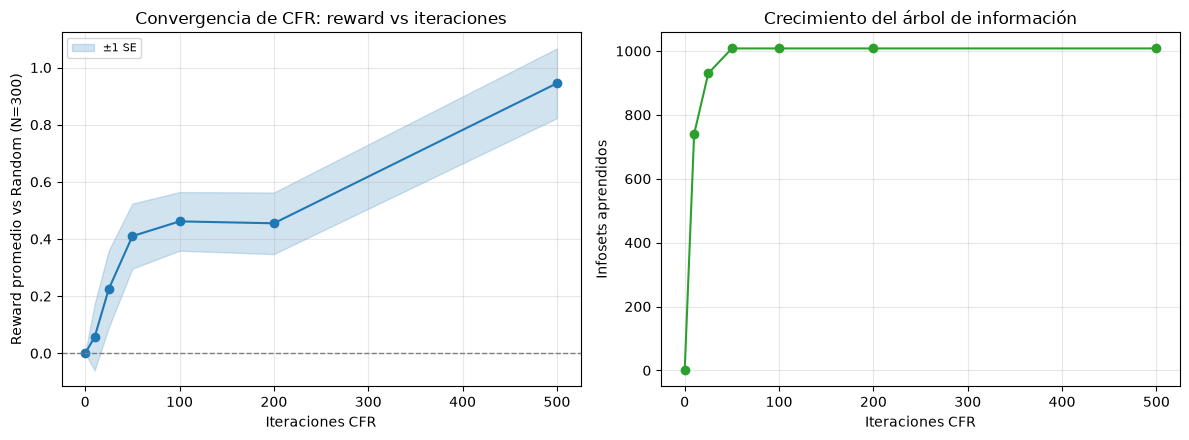

In [33]:
iter_checkpoints = [10, 25, 50, 100, 200, 500]
N_EVAL_CFR = 300

g_conv = Leduc()
cfr_conv = CounterFactualRegret(game=g_conv, agent='player_0')

conv_rows = [{'iteraciones': 0, 'avg_reward': 0.0, 'std_reward': 0.0, 'infosets': 0}]
prev = 0
for target in iter_checkpoints:
    cfr_conv.train(niter=target - prev)
    prev = target
    g_eval = Leduc()
    cfr_conv.game = g_eval
    rews = run_raw(g_eval, {
        'player_0': cfr_conv,
        'player_1': RandomAgent(game=g_eval, agent='player_1'),
    }, N=N_EVAL_CFR)
    cfr_conv.game = g_conv
    conv_rows.append({
        'iteraciones': target,
        'avg_reward': float(np.mean(rews)),
        'std_reward': float(np.std(rews)),
        'infosets': len(cfr_conv.node_dict),
    })
    print(f'  iter={target:>4}  reward_medio={np.mean(rews):.3f}  infosets={len(cfr_conv.node_dict)}')

df_conv = pd.DataFrame(conv_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(df_conv.iteraciones, df_conv.avg_reward, marker='o', color='tab:blue')
axes[0].fill_between(
    df_conv.iteraciones,
    df_conv.avg_reward - df_conv.std_reward / np.sqrt(N_EVAL_CFR),
    df_conv.avg_reward + df_conv.std_reward / np.sqrt(N_EVAL_CFR),
    alpha=0.2, color='tab:blue', label='\u00b11 SE',
)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('Iteraciones CFR')
axes[0].set_ylabel(f'Reward promedio vs Random (N={N_EVAL_CFR})')
axes[0].set_title('Convergencia de CFR: reward vs iteraciones')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(df_conv.iteraciones, df_conv.infosets, marker='o', color='tab:green')
axes[1].set_xlabel('Iteraciones CFR')
axes[1].set_ylabel('Infosets aprendidos')
axes[1].set_title('Crecimiento del árbol de información')
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'convergencia_cfr.png')
plt.show()

### CFR vs CFR

In [34]:
g = Leduc()
for agent in g.agents:
    cfr_agents[agent].game = g
results, mean = run(g, cfr_agents, N=2000)
print("=== CFR (agent_0) vs CFR (agent_1) ===")
print(f"Distribución recompensas agent_0: {results}")
print(f"Media recompensa agent_0: {mean:.4f}")

=== CFR (agent_0) vs CFR (agent_1) ===
Distribución recompensas agent_0: {np.float64(-7.0): np.int64(13), np.float64(-6.0): np.int64(53), np.float64(-5.0): np.int64(61), np.float64(-4.0): np.int64(22), np.float64(-3.0): np.int64(118), np.float64(-2.0): np.int64(146), np.float64(-1.0): np.int64(283), np.float64(-0.5): np.int64(132), np.float64(0.0): np.int64(168), np.float64(0.5): np.int64(332), np.float64(1.0): np.int64(312), np.float64(2.0): np.int64(123), np.float64(3.0): np.int64(97), np.float64(4.0): np.int64(50), np.float64(5.0): np.int64(46), np.float64(6.0): np.int64(29), np.float64(7.0): np.int64(14)}
Media recompensa agent_0: -0.0400


Figura guardada en ../informe/figures/Leduc/dist_cfr_vs_cfr.png


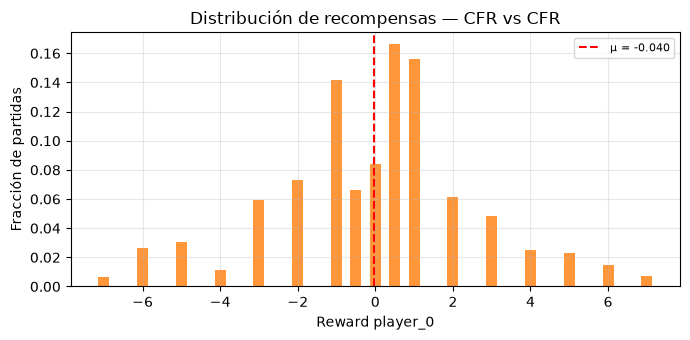

In [35]:
means_summary['CFR vs CFR'] = mean

fig, ax = plt.subplots(figsize=(7, 3.5))
plot_dist(results, mean, 'Distribución de recompensas — CFR vs CFR', ax, color='tab:orange')
fig.tight_layout()
savefig(fig, 'dist_cfr_vs_cfr.png')
plt.show()

Figura guardada en ../informe/figures/Leduc/evo_cfr_vs_cfr.png


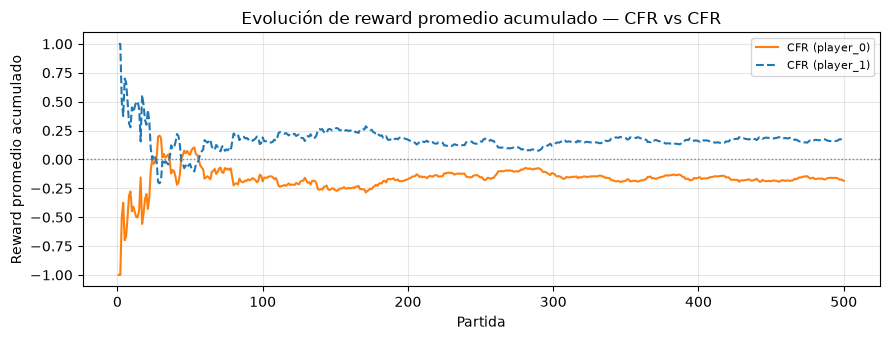

In [36]:
N_EVO = 500
g_evo = Leduc()
for a in g_evo.agents:
    cfr_agents[a].game = g_evo
rews_evo = run_raw(g_evo, cfr_agents, N=N_EVO)

fig, ax = plt.subplots(figsize=(9, 3.5))
plot_evolution(rews_evo, 'Evolución de reward promedio acumulado — CFR vs CFR',
               ax, color_p0='tab:orange', color_p1='tab:blue',
               label_p0='CFR (player_0)', label_p1='CFR (player_1)')
fig.tight_layout()
savefig(fig, 'evo_cfr_vs_cfr.png')
plt.show()

---
## ISMCTS — Information Set Monte Carlo Tree Search

ISMCTS extiende MCTS para juegos con información imperfecta.
En cada simulación samplea un estado posible compatible con la información del agente y corre MCTS sobre ese estado determinizado.

`Leduc` implementa `sample_from_infoset(agent)`: toma la mano del oponente más el mazo restante como pool de cartas desconocidas, asigna una carta al oponente al azar y devuelve el estado determinizado. Así, cada simulación parte de un mundo posible distinto, consistente con lo que el agente sabe (su carta privada + el historial público), lo que equivale al algoritmo IS-MCTS con *determinización por partición*.

### ISMCTS vs Random

In [37]:
g = Leduc()
agents = {
    'player_0': InformationSetMCTS(game=g, agent='player_0', simulations=50, rollouts=5),
    'player_1': RandomAgent(game=g, agent='player_1')
}
results, mean = run(g, agents, N=200)
print("=== ISMCTS (agent_0) vs Random (agent_1) ===")
print(f"Distribución recompensas agent_0: {results}")
print(f"Media recompensa agent_0: {mean:.4f}")

=== ISMCTS (agent_0) vs Random (agent_1) ===
Distribución recompensas agent_0: {np.float64(-7.0): np.int64(2), np.float64(-5.0): np.int64(1), np.float64(-4.0): np.int64(3), np.float64(-3.0): np.int64(5), np.float64(-2.0): np.int64(7), np.float64(-1.0): np.int64(20), np.float64(-0.5): np.int64(8), np.float64(0.0): np.int64(8), np.float64(0.5): np.int64(33), np.float64(1.0): np.int64(49), np.float64(2.0): np.int64(27), np.float64(3.0): np.int64(16), np.float64(4.0): np.int64(5), np.float64(5.0): np.int64(9), np.float64(6.0): np.int64(3), np.float64(7.0): np.int64(3)}
Media recompensa agent_0: 0.9422


Figura guardada en ../informe/figures/Leduc/dist_ismcts_vs_random.png


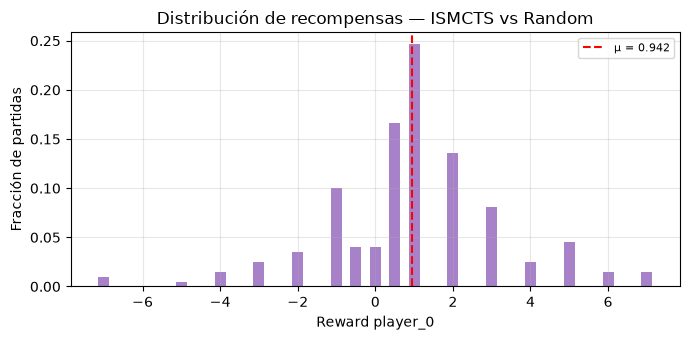

In [38]:
means_summary['ISMCTS vs Random'] = mean

fig, ax = plt.subplots(figsize=(7, 3.5))
plot_dist(results, mean, 'Distribución de recompensas — ISMCTS vs Random', ax, color='tab:purple')
fig.tight_layout()
savefig(fig, 'dist_ismcts_vs_random.png')
plt.show()

Figura guardada en ../informe/figures/Leduc/evo_ismcts_vs_random.png


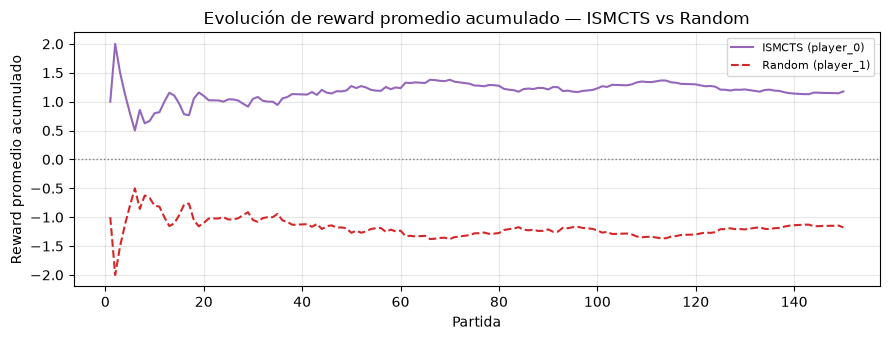

In [39]:
N_EVO = 150
g_evo = Leduc()
rews_evo = run_raw(g_evo, {
    'player_0': InformationSetMCTS(game=g_evo, agent='player_0', simulations=50, rollouts=5),
    'player_1': RandomAgent(game=g_evo, agent='player_1'),
}, N=N_EVO)

fig, ax = plt.subplots(figsize=(9, 3.5))
plot_evolution(rews_evo, 'Evolución de reward promedio acumulado — ISMCTS vs Random',
               ax, color_p0='tab:purple', color_p1='tab:red',
               label_p0='ISMCTS (player_0)', label_p1='Random (player_1)')
fig.tight_layout()
savefig(fig, 'evo_ismcts_vs_random.png')
plt.show()

### ISMCTS vs CFR

In [40]:
g = Leduc()
cfr_agents['player_1'].game = g
agents = {
    'player_0': InformationSetMCTS(game=g, agent='player_0', simulations=50, rollouts=5),
    'player_1': cfr_agents['player_1']
}
results, mean = run(g, agents, N=200)
print("=== ISMCTS (agent_0) vs CFR (agent_1) ===")
print(f"Distribución recompensas agent_0: {results}")
print(f"Media recompensa agent_0: {mean:.4f}")

=== ISMCTS (agent_0) vs CFR (agent_1) ===
Distribución recompensas agent_0: {np.float64(-7.0): np.int64(2), np.float64(-6.0): np.int64(1), np.float64(-5.0): np.int64(1), np.float64(-4.0): np.int64(1), np.float64(-3.0): np.int64(12), np.float64(-2.0): np.int64(17), np.float64(-1.0): np.int64(25), np.float64(-0.5): np.int64(12), np.float64(0.0): np.int64(22), np.float64(0.5): np.int64(32), np.float64(1.0): np.int64(37), np.float64(2.0): np.int64(6), np.float64(3.0): np.int64(8), np.float64(4.0): np.int64(5), np.float64(5.0): np.int64(6), np.float64(6.0): np.int64(6), np.float64(7.0): np.int64(6)}
Media recompensa agent_0: 0.4372


Figura guardada en ../informe/figures/Leduc/dist_ismcts_vs_cfr.png


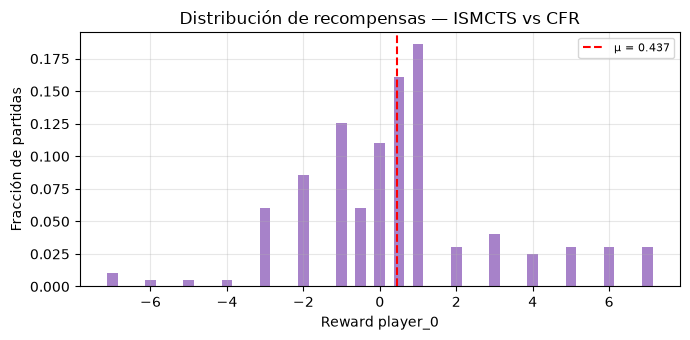

In [41]:
means_summary['ISMCTS vs CFR'] = mean

fig, ax = plt.subplots(figsize=(7, 3.5))
plot_dist(results, mean, 'Distribución de recompensas — ISMCTS vs CFR', ax, color='tab:purple')
fig.tight_layout()
savefig(fig, 'dist_ismcts_vs_cfr.png')
plt.show()

Figura guardada en ../informe/figures/Leduc/evo_ismcts_vs_cfr.png


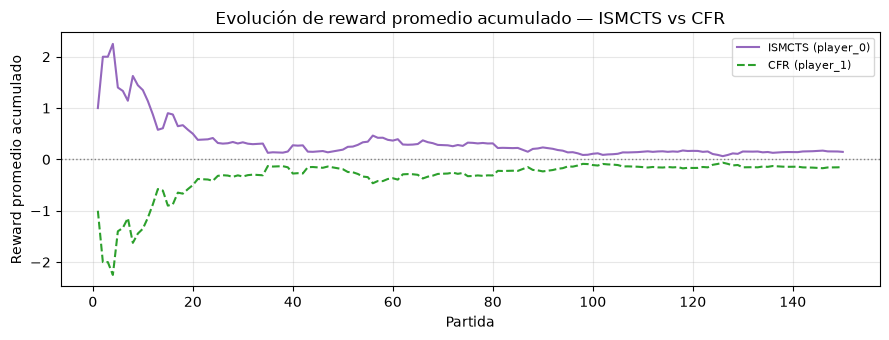

In [42]:
N_EVO = 150
g_evo = Leduc()
cfr_agents['player_1'].game = g_evo
rews_evo = run_raw(g_evo, {
    'player_0': InformationSetMCTS(game=g_evo, agent='player_0', simulations=50, rollouts=5),
    'player_1': cfr_agents['player_1'],
}, N=N_EVO)

fig, ax = plt.subplots(figsize=(9, 3.5))
plot_evolution(rews_evo, 'Evolución de reward promedio acumulado — ISMCTS vs CFR',
               ax, color_p0='tab:purple', color_p1='tab:green',
               label_p0='ISMCTS (player_0)', label_p1='CFR (player_1)')
fig.tight_layout()
savefig(fig, 'evo_ismcts_vs_cfr.png')
plt.show()

#### Efecto de simulaciones en ISMCTS

Variamos `simulations` en `[10, 25, 50, 100]` manteniendo `rollouts=5` fijo.
El subplot izquierdo muestra el reward promedio de ISMCTS contra ambos oponentes.
El derecho muestra el costo de cómputo (tiempo promedio por decisión, escala log).

> En cada simulación, ISMCTS llama a `sample_from_infoset`: aleatoriza la carta del oponente
> desde el pool de cartas desconocidas antes de correr MCTS sobre ese estado determinizado.

  sims= 10  vs Random: 0.342  vs CFR: 0.617  ms/dec: 43.5
  sims= 25  vs Random: 0.675  vs CFR: 0.508  ms/dec: 105.9
  sims= 50  vs Random: 1.100  vs CFR: 0.508  ms/dec: 203.9
  sims=100  vs Random: 1.042  vs CFR: 0.742  ms/dec: 399.6
Figura guardada en ../informe/figures/Leduc/ismcts_simulations.png


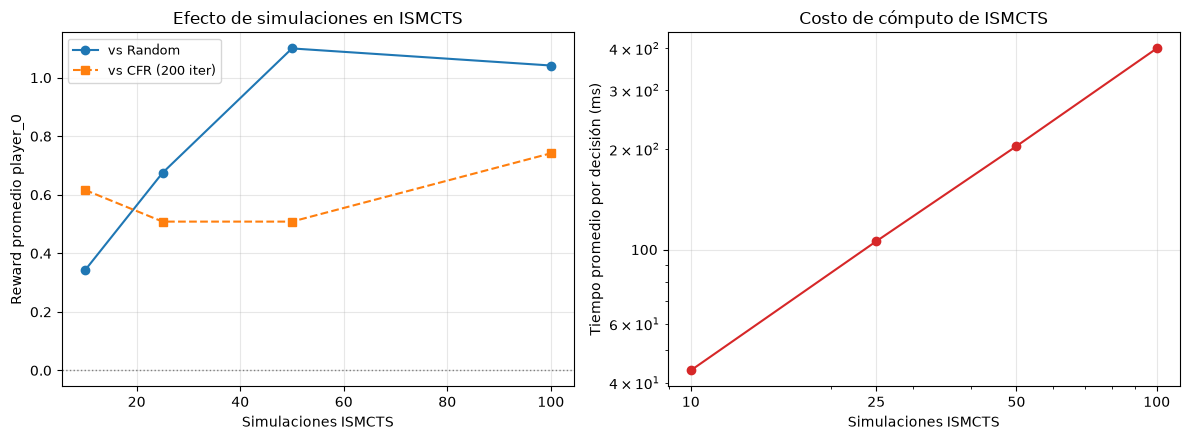

In [43]:
sim_grid = [10, 25, 50, 100]
N_SIMS = 60

g_cfr_sims = Leduc()
cfr_sims = CounterFactualRegret(game=g_cfr_sims, agent='player_1')
cfr_sims.train(niter=200)

sims_rows = []
for sims in sim_grid:
    g = Leduc()
    rews_r, times_r = run_timed(g, {
        'player_0': InformationSetMCTS(game=g, agent='player_0', simulations=sims, rollouts=5),
        'player_1': RandomAgent(game=g, agent='player_1'),
    }, N=N_SIMS)

    g = Leduc()
    cfr_sims.game = g
    rews_c, times_c = run_timed(g, {
        'player_0': InformationSetMCTS(game=g, agent='player_0', simulations=sims, rollouts=5),
        'player_1': cfr_sims,
    }, N=N_SIMS)

    sims_rows.append(dict(
        simulations=sims,
        avg_reward_vs_random=float(np.mean(rews_r)),
        avg_reward_vs_cfr=float(np.mean(rews_c)),
        avg_time_ms=times_r['player_0'] * 1000,
    ))
    print(f'  sims={sims:>3}  vs Random: {np.mean(rews_r):.3f}  '
          f'vs CFR: {np.mean(rews_c):.3f}  ms/dec: {times_r["player_0"]*1000:.1f}')

df_sims = pd.DataFrame(sims_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(df_sims.simulations, df_sims.avg_reward_vs_random, marker='o', label='vs Random')
axes[0].plot(df_sims.simulations, df_sims.avg_reward_vs_cfr, marker='s',
             linestyle='--', label='vs CFR (200 iter)')
axes[0].axhline(0, color='gray', linestyle=':', linewidth=1)
axes[0].set_xlabel('Simulaciones ISMCTS')
axes[0].set_ylabel('Reward promedio player_0')
axes[0].set_title('Efecto de simulaciones en ISMCTS')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(df_sims.simulations, df_sims.avg_time_ms, marker='o', color='tab:red')
axes[1].set_xlabel('Simulaciones ISMCTS')
axes[1].set_ylabel('Tiempo promedio por decisión (ms)')
axes[1].set_title('Costo de cómputo de ISMCTS')
axes[1].set_xscale('log')
axes[1].xaxis.set_major_formatter(PLAIN_FMT)
axes[1].xaxis.set_minor_formatter(NullFormatter())
axes[1].set_xticks(sim_grid)
axes[1].set_yscale('log')
axes[1].yaxis.set_major_formatter(PLAIN_FMT)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'ismcts_simulations.png')
plt.show()

### CFR vs ISMCTS (posiciones intercambiadas)

In [44]:
g = Leduc()
cfr_agents['player_0'].game = g
agents = {
    'player_0': cfr_agents['player_0'],
    'player_1': InformationSetMCTS(game=g, agent='player_1', simulations=50, rollouts=5)
}
results, mean = run(g, agents, N=200)
print("=== CFR (agent_0) vs ISMCTS (agent_1) ===")
print(f"Distribución recompensas agent_0: {results}")
print(f"Media recompensa agent_0: {mean:.4f}")

=== CFR (agent_0) vs ISMCTS (agent_1) ===
Distribución recompensas agent_0: {np.float64(-7.0): np.int64(5), np.float64(-6.0): np.int64(5), np.float64(-5.0): np.int64(11), np.float64(-4.0): np.int64(1), np.float64(-3.0): np.int64(17), np.float64(-2.0): np.int64(13), np.float64(-1.0): np.int64(24), np.float64(-0.5): np.int64(10), np.float64(0.0): np.int64(26), np.float64(0.5): np.int64(14), np.float64(1.0): np.int64(35), np.float64(2.0): np.int64(16), np.float64(3.0): np.int64(17), np.float64(4.0): np.int64(1), np.float64(5.0): np.int64(1), np.float64(6.0): np.int64(1), np.float64(7.0): np.int64(2)}
Media recompensa agent_0: -0.3819


Figura guardada en ../informe/figures/Leduc/dist_cfr_vs_ismcts.png


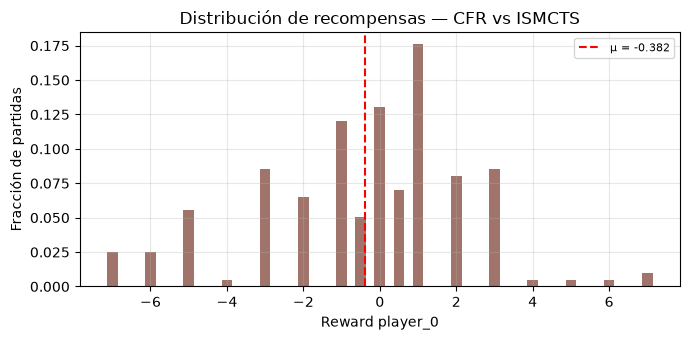

In [45]:
means_summary['CFR vs ISMCTS'] = mean

fig, ax = plt.subplots(figsize=(7, 3.5))
plot_dist(results, mean, 'Distribución de recompensas — CFR vs ISMCTS', ax, color='tab:brown')
fig.tight_layout()
savefig(fig, 'dist_cfr_vs_ismcts.png')
plt.show()

Figura guardada en ../informe/figures/Leduc/evo_cfr_vs_ismcts.png


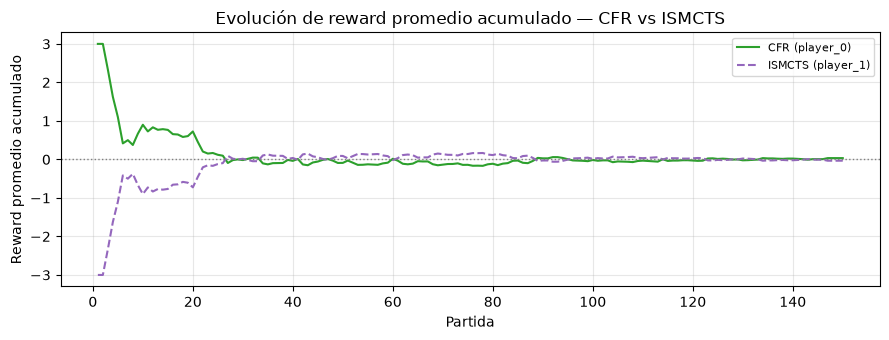

In [46]:
N_EVO = 150
g_evo = Leduc()
cfr_agents['player_0'].game = g_evo
rews_evo = run_raw(g_evo, {
    'player_0': cfr_agents['player_0'],
    'player_1': InformationSetMCTS(game=g_evo, agent='player_1', simulations=50, rollouts=5),
}, N=N_EVO)

fig, ax = plt.subplots(figsize=(9, 3.5))
plot_evolution(rews_evo, 'Evolución de reward promedio acumulado — CFR vs ISMCTS',
               ax, color_p0='tab:green', color_p1='tab:purple',
               label_p0='CFR (player_0)', label_p1='ISMCTS (player_1)')
fig.tight_layout()
savefig(fig, 'evo_cfr_vs_ismcts.png')
plt.show()

---
## Resumen

| Matchup | Media reward agent_0 | Esperado |
|---|---|---|
| CFR vs Random | > 0 | CFR explota al random |
| CFR vs CFR | ≈ 0 | Equilibrio Nash aproximado |
| ISMCTS vs Random | > 0 | ISMCTS con determinización gana |
| ISMCTS vs CFR | variable | CFR entrenado puede resistir |
| CFR vs ISMCTS | variable | Posición 0 vs ISMCTS |

**CFR** converge a Nash en juegos de 2 jugadores de suma cero.  
**ISMCTS** usa `sample_from_infoset` para determinizar el estado antes de cada simulación, razonando correctamente bajo incertidumbre sobre la carta oculta del oponente.

### Resumen visual de medias

Figura guardada en ../informe/figures/Leduc/resumen_medias.png


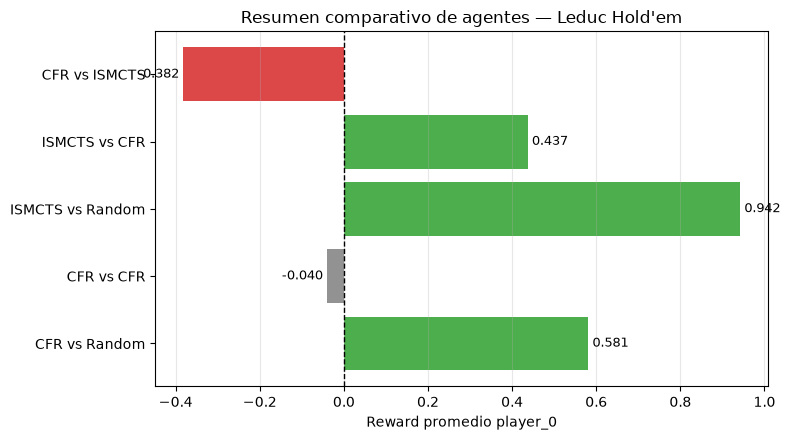

In [47]:
labels_s  = list(means_summary.keys())
vals_s    = [means_summary[k] for k in labels_s]
colors_s  = ['tab:gray' if abs(v) < 0.05 else ('tab:green' if v > 0 else 'tab:red')
             for v in vals_s]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(labels_s, vals_s, color=colors_s, alpha=0.85)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Reward promedio player_0')
ax.set_title("Resumen comparativo de agentes — Leduc Hold'em")
ax.grid(alpha=0.3, axis='x')
fig.tight_layout()
savefig(fig, 'resumen_medias.png')
plt.show()

### Benchmark de tiempos

Comparación del tiempo de decisión por agente sobre el mismo número de partidas.
**CFR** es O(1) en inferencia (lookup en la tabla de infosets ya entrenada).
**ISMCTS** escala linealmente con `simulations`.
Todos juegan como `player_0` contra `RandomAgent` fijo como `player_1`.

  CFR (200 iter)             0.004 ms/dec
  ISMCTS (sims=10)           42.985 ms/dec
  ISMCTS (sims=25)           104.133 ms/dec
  ISMCTS (sims=50)           214.854 ms/dec
  ISMCTS (sims=100)          404.465 ms/dec
Figura guardada en ../informe/figures/Leduc/benchmark_tiempos.png


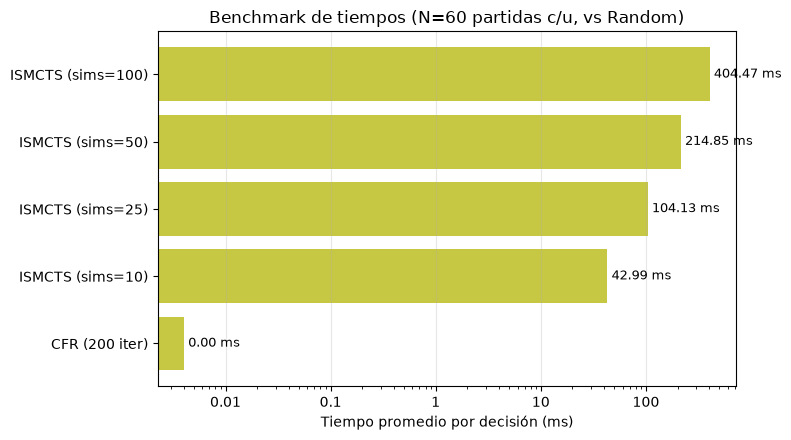

In [48]:
N_BENCH = 60

g_bench_cfr = Leduc()
cfr_bench   = CounterFactualRegret(game=g_bench_cfr, agent='player_0')
cfr_bench.train(niter=200)

def _set_game(agent, g):
    agent.game = g
    return agent

bench_configs = [
    ('CFR (200 iter)',    lambda g: _set_game(cfr_bench, g)),
    ('ISMCTS (sims=10)',  lambda g: InformationSetMCTS(game=g, agent='player_0', simulations=10,  rollouts=5)),
    ('ISMCTS (sims=25)',  lambda g: InformationSetMCTS(game=g, agent='player_0', simulations=25,  rollouts=5)),
    ('ISMCTS (sims=50)',  lambda g: InformationSetMCTS(game=g, agent='player_0', simulations=50,  rollouts=5)),
    ('ISMCTS (sims=100)', lambda g: InformationSetMCTS(game=g, agent='player_0', simulations=100, rollouts=5)),
]

bench_rows = []
for label, factory in bench_configs:
    g = Leduc()
    _, times = run_timed(g, {
        'player_0': factory(g),
        'player_1': RandomAgent(game=g, agent='player_1'),
    }, N=N_BENCH)
    bench_rows.append({'agente': label, 'avg_time_ms': times['player_0'] * 1000})
    print(f'  {label:<25}  {times["player_0"]*1000:.3f} ms/dec')

df_bench = pd.DataFrame(bench_rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(df_bench.agente, df_bench.avg_time_ms, color='tab:olive', alpha=0.85)
ax.bar_label(bars, fmt='%.2f ms', padding=3, fontsize=9)
ax.set_xlabel('Tiempo promedio por decisión (ms)')
ax.set_title(f"Benchmark de tiempos (N={N_BENCH} partidas c/u, vs Random)")
ax.set_xscale('log')
ax.xaxis.set_major_formatter(PLAIN_FMT)
ax.xaxis.set_minor_formatter(NullFormatter())
ax.grid(alpha=0.3, axis='x')
fig.tight_layout()
savefig(fig, 'benchmark_tiempos.png')
plt.show()